In [11]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding MySQL table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv', 'order_items')
]

# MySQL database connection
conn = mysql.connector.connect(
    host='localhost',
    user='laksh',
    password='yourpassword',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder path containing the CSV files
folder_path = 'C:/Users/laksh/OneDrive/Desktop/e commerce'

# Function to map pandas dtypes to MySQL column types
def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

# Loop through each CSV file and convert it to a SQL table
for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)

    if not os.path.exists(file_path):
        print(f"[WARNING] File not found: {file_path}")
        continue

    try:
        # Read the CSV file (with encoding fallback)
        df = pd.read_csv(file_path, encoding='utf-8', on_bad_lines='skip')

        # Replace NaNs with None to handle SQL NULLs
        df = df.where(pd.notnull(df), None)

        print(f"\nProcessing '{csv_file}' into table `{table_name}`")
        print("Null values per column:\n", df.isnull().sum())

        # Clean column names (replace space, dot, dash with underscore)
        df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

        # Drop table if it already exists (optional: for fresh conversion)
        cursor.execute(f"DROP TABLE IF EXISTS `{table_name}`")

        # Generate CREATE TABLE query
        columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
        create_table_query = f'CREATE TABLE `{table_name}` ({columns})'
        cursor.execute(create_table_query)

        # Insert data into the table
        for _, row in df.iterrows():
            values = tuple(None if pd.isna(x) else x for x in row)
            sql = f"INSERT INTO `{table_name}` ({', '.join([f'`{col}`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
            cursor.execute(sql, values)

        # Commit after each table
        conn.commit()
        print(f"✅ Data inserted into `{table_name}` successfully.")

    except Exception as e:
        print(f"❌ Error while processing '{csv_file}': {e}")

# Close MySQL connection
conn.close()
print("\nAll files processed. Connection closed.")



Processing 'customers.csv' into table `customers`
Null values per column:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
✅ Data inserted into `customers` successfully.

Processing 'orders.csv' into table `orders`
Null values per column:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
✅ Data inserted into `orders` successfully.

Processing 'sellers.csv' into table `sellers`
Null values per column:
 seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64
✅ Data inserted into `sellers` successfully.

Processing 'products.csv' into table `pr

In [1]:
pip install pandas

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------- ----------------------------- 2.9/11.0 MB 20.9 MB/s eta 0:00:01
   ----------------- ---------------------- 4.7/11.0 MB 13.3 MB/s eta 0:00:01
   --------------------- ------------------ 5.8/11.0 MB 10.0 MB/s eta 0:00:01
   ------------------------ --------------- 6.8/11.0 MB 8.5 MB/s eta 0:00:01
   --------------------------- ------------ 7.6/11.0 MB 7.8 MB/s eta 0:00:01
   ----------------------------- ---------- 8.1/11.0 MB 7.1 MB/s eta 0:00:01
   ------------------------------- -------- 8.7/11.0 MB 6.3 MB/s eta 0:00:01
   ---------------------------------- ----- 9.4/11.0 MB 5.8 MB/s eta 0:00:01
   ------------------------------------- -- 10.2/11.0 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------  10.7/11.0 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 5.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install mysql-connector-python

   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ------- -------------------------------- 2.9/16.4 MB 18.0 MB/s eta 0:00:01
   ----------- ---------------------------- 4.7/16.4 MB 12.9 MB/s eta 0:00:01
   -------------- ------------------------- 5.8/16.4 MB 10.0 MB/s eta 0:00:02
   --------------- ------------------------ 6.3/16.4 MB 8.0 MB/s eta 0:00:02
   ---------------- ----------------------- 6.6/16.4 MB 7.1 MB/s eta 0:00:02
   ----------------- ---------------------- 7.1/16.4 MB 6.0 MB/s eta 0:00:02
   ----------------- ---------------------- 7.3/16.4 MB 5.2 MB/s eta 0:00:02
   ------------------ --------------------- 7.6/16.4 MB 4.8 MB/s eta 0:00:02
   ------------------- -------------------- 8.1/16.4 MB 4.4 MB/s eta 0:00:02
   --------------------- ------------------ 8.7/16.4 MB 4.2 MB/s eta 0:00:02
   ----------------------- ---------------- 9.4/16.4 MB 4.1 MB/s eta 0:00:02
   ------------------------ --------------- 10.2/16.4 MB 4.1 MB/s eta 0:00:02
  


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(
    host='localhost',
    user='laksh',
    password='yourpassword',
    database='ecommerce'
)
cur = db.cursor()


#list all unique cities where customers are located

In [ ]:
query="""select distinct customer_city from customers"""
cur.execute(query)
data=cur.fetchall()
data

#count the order placed in 2017

In [18]:
query="""select count(order_id) from orders where year(order_purchase_timestamp)=2017"""
cur.execute(query)
data=cur.fetchall()
data

[(45101,)]

#count the number of customer in each state

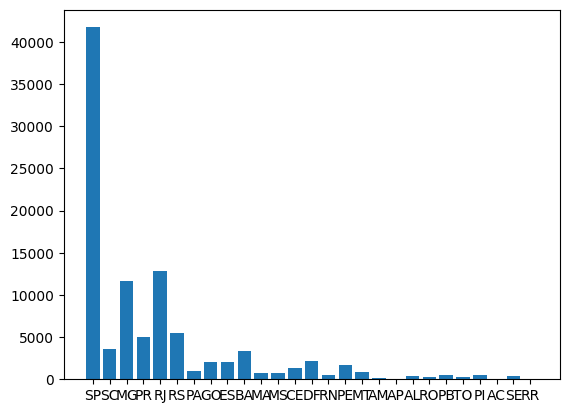

In [35]:
query="""select customer_state,count(customer_id) from customers group by customer_state"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["state","customer_count"])
plt.bar(df["state"],df["customer_count"])
plt.show()

#calculate the total no. of orders per month of 2018

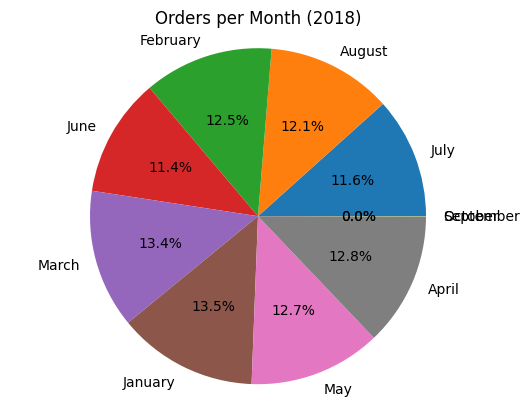

In [48]:
query = """
select monthname(order_purchase_timestamp) as month,
       count(order_id) as ordercount 
from orders 
where year(order_purchase_timestamp) = 2018 
group by month
"""

cur.execute(query)
data = cur.fetchall()

# Convert to DataFrame
df = pd.DataFrame(data, columns=["month", "ordercount"])

# Plot
plt.pie(df["ordercount"], labels=df["month"], autopct='%1.1f%%')
plt.title("Orders per Month (2018)")
plt.axis("equal")  # Optional: Makes the pie chart a circle
plt.show()


#find the average no. of products per orders group by customer city

In [56]:
query = """
with count_per_order as
(select orders.order_id,orders.customer_id,count(order_items.order_id) as oc
from orders join order_items on orders.order_id=order_items.order_id
group by orders.order_id,orders.customer_id)
 
select customers.customer_city,round(avg(count_per_order.oc),2) as average_orders from customers 
join count_per_order on customers.customer_id=count_per_order.customer_id
group by customers.customer_city order by average_orders desc
"""

cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data)
df.head(10)

,0,1
0,padre carvalho,7.00
1,celso ramos,6.50
2,datas,6.00
3,candido godoi,6.00
4,matias olimpio,5.00
5,cidelandia,4.00
6,picarra,4.00
7,morro de sao paulo,4.00
8,teixeira soares,4.00
9,curralinho,4.00


#calculate the percentage of total revenue contributed by each product cateogry

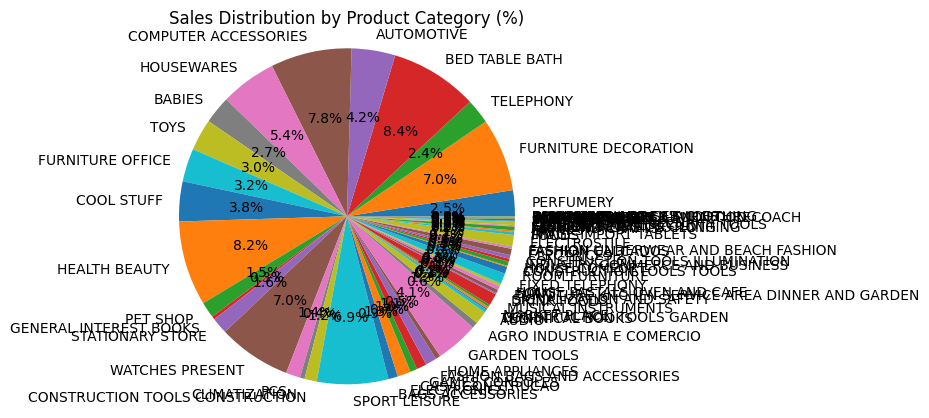

In [59]:
query = """
SELECT 
    UPPER(products.product_category) AS category,
    (SUM(payments.payment_value) / (SELECT SUM(payment_value) FROM payments)) * 100 AS sales 
FROM products
JOIN order_items ON products.product_id = order_items.product_id
JOIN payments ON payments.order_id = order_items.order_id
GROUP BY category
"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["category", "percentage distribution"])

plt.pie(df["percentage distribution"], labels=df["category"], autopct='%1.1f%%')
plt.title("Sales Distribution by Product Category (%)")
plt.axis("equal")  # Keeps pie chart as a circle
plt.show()


#identify the correlation between product price and the number of times products has been purchased

In [63]:
query = """
select 
products.product_category,count(order_items.product_id),avg(order_items.price)
from products join order_items on products.product_id=order_items.product_id
group by products.product_category;
"""
cur.execute(query)
data = cur.fetchall()
data

[('HEALTH BEAUTY', 9670, 130.16353060696215),
 ('sport leisure', 8641, 114.34428525509044),
 ('Cool Stuff', 3796, 167.3579693616881),
 ('computer accessories', 7827, 116.51390283098924),
 ('Watches present', 5991, 201.13598356691074),
 ('housewares', 6964, 90.78814774131995),
 ('electronics', 2767, 57.913530686033475),
 (None, 1603, 111.99955065579096),
 ('toys', 4117, 117.54836056711375),
 ('bed table bath', 11115, 93.2963274885822),
 ('Games consoles', 1137, 138.4918385294308),
 ('automotive', 4235, 139.95752318972256),
 ('Furniture Decoration', 8334, 87.56449391603299),
 ('home appliances', 771, 103.98382645358372),
 ('telephony', 4545, 71.21397786418466),
 ('Construction Tools Construction', 929, 155.73475766836378),
 ('perfumery', 3419, 116.73731166530541),
 ('stationary store', 2517, 91.75336903970678),
 ('Room Furniture', 503, 137.01105334317944),
 ('Fashion Bags and Accessories', 2031, 75.24546548757924),
 ('Garden tools', 4347, 111.63019600313835),
 ('Fashion Underwear and Bea

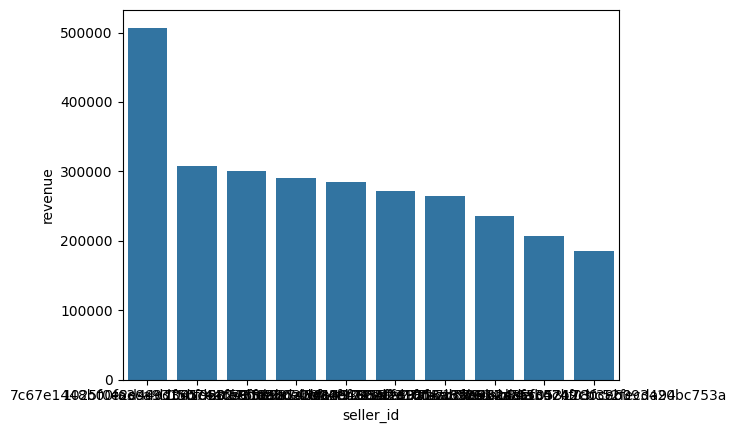

In [72]:
query = """
SELECT *, DENSE_RANK() OVER (ORDER BY revenue DESC) AS rn
FROM (
    SELECT 
        order_items.seller_id, 
        SUM(payments.payment_value) AS revenue
    FROM order_items
    JOIN payments 
        ON order_items.order_id = payments.order_id
    GROUP BY order_items.seller_id
) AS a;
"""
cur.execute(query)
data = cur.fetchall()

# Correct column names
df = pd.DataFrame(data, columns=["seller_id", "revenue", "rn"])

# Take top 10 sellers
df = df.head(10)

# Bar plot
sns.barplot(x="seller_id", y="revenue", data=df)
plt.show()


#calculate the moving average of order values for each customer over their order history

In [77]:

query = """
SELECT 
    customer_id, 
    order_purchase_timestamp, 
    payment,
    AVG(payment) OVER (
        PARTITION BY customer_id 
        ORDER BY order_purchase_timestamp 
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS mov_avg
FROM (
    SELECT 
        orders.customer_id,
        orders.order_purchase_timestamp,
        payments.payment_value AS payment
    FROM payments
    JOIN orders ON payments.order_id = orders.order_id
) AS sub;
"""
cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data,columns=["customer_id","order_purchase_timestamp","payment","averag of payments"])
df.head(30)

,customer_id,order_purchase_timestamp,payment,averag of payments
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
5,0004164d20a9e969af783496f3408652,2017-04-12 08:35:12,71.80,71.800003
6,000419c5494106c306a97b5635748086,2018-03-02 17:47:40,49.40,49.400002
7,00046a560d407e99b969756e0b10f282,2017-12-18 11:08:30,166.59,166.589996
8,00050bf6e01e69d5c0fd612f1bcfb69c,2017-09-17 16:04:44,85.23,85.230003
9,000598caf2ef4117407665ac33275130,2018-08-11 12:14:35,1255.71,1255.709961


#calculate the cummulative sales for each year

In [80]:
query = """
SELECT 
    years,
    months,
    payment,
    SUM(payment) OVER (ORDER BY years, months) AS cumulative_payment
FROM (
    SELECT 
        YEAR(orders.order_purchase_timestamp) AS years,
        MONTHNAME(orders.order_purchase_timestamp) AS months,
        ROUND(SUM(payments.payment_value), 2) AS payment
    FROM orders 
    JOIN payments ON orders.order_id = payments.order_id
    GROUP BY years, months
) AS sub
ORDER BY years, months;
"""
cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data,columns=["years","monthname","payment","cummulative payments"])
df

,years,monthname,payment,cummulative payments
0,2016,December,19.62,19.62
1,2016,October,59090.48,59110.10
2,2016,September,252.24,59362.34
3,2017,April,417788.03,477150.37
4,2017,August,674396.32,1151546.69
5,2017,December,878401.48,2029948.17
6,2017,February,291908.01,2321856.18
7,2017,January,138488.04,2460344.22
8,2017,July,592382.92,3052727.14
9,2017,June,511276.38,3564003.52


#calculate year over year growth rate of total sales

In [83]:
query = """
SELECT 
    years,
    total_sales,
    LAG(total_sales) OVER (ORDER BY years) AS prev_year_sales,
    ROUND(
        (total_sales - LAG(total_sales) OVER (ORDER BY years)) 
        / NULLIF(LAG(total_sales) OVER (ORDER BY years), 0) * 100,
        2
    ) AS yoy_growth_percentage
FROM (
    SELECT 
        YEAR(orders.order_purchase_timestamp) AS years,
        SUM(payments.payment_value) AS total_sales
    FROM orders
    JOIN payments ON orders.order_id = payments.order_id
    GROUP BY years
) AS yearly_sales;

"""
cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data,columns=["years","totalsales","lag payment","growth rate"])
df

,years,totalsales,lag payment,growth rate
0,2016,5.936234e+04,NaN,NaN
1,2017,7.249747e+06,5.936234e+04,12112.7
2,2018,8.699763e+06,7.249747e+06,20.0


#calculate the retention rate of the customer defined as the percentage of customers who make another purchase within 6 month of their first purchase

In [85]:
query="""WITH a AS (
    SELECT 
        customers.customer_id,
        MIN(orders.order_purchase_timestamp) AS first_order
    FROM customers 
    JOIN orders ON customers.customer_id = orders.customer_id
    GROUP BY customers.customer_id
),
b AS (
    SELECT 
        a.customer_id,
        COUNT(DISTINCT orders.order_purchase_timestamp) AS next_order
    FROM a 
    JOIN orders ON orders.customer_id = a.customer_id
        AND orders.order_purchase_timestamp > a.first_order
        AND orders.order_purchase_timestamp < DATE_ADD(a.first_order, INTERVAL 6 MONTH)
    GROUP BY a.customer_id
)

SELECT 
    100.0 * COUNT(DISTINCT b.customer_id) / COUNT(DISTINCT a.customer_id) AS repeat_rate_percentage
FROM a
LEFT JOIN b ON a.customer_id = b.customer_id;
"""
cur.execute(query)
data=cur.fetchall()
data

[(Decimal('0.00000'),)]

#identify the top 3 customer who spend the most of his monwy in each year

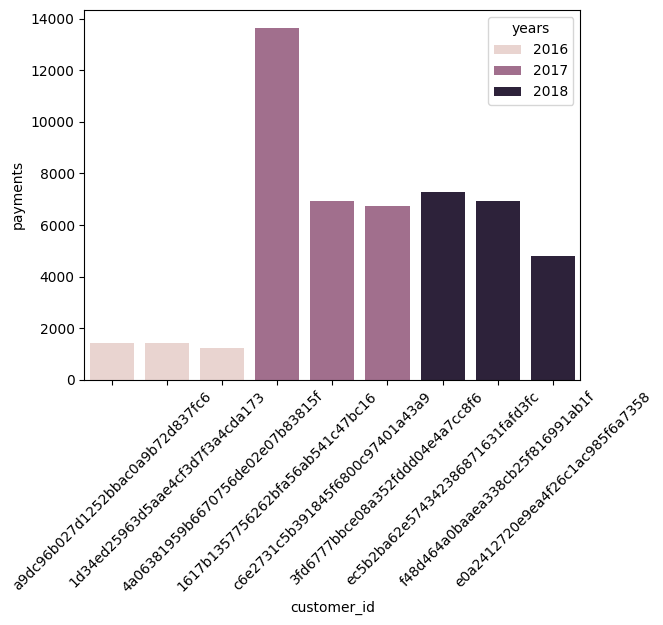

In [94]:
query="""select years,customer_id,payment,d_rank from
(select year(orders.order_purchase_timestamp) as years,
orders.customer_id,sum(payments.payment_value) as payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value)desc) d_rank
from orders join payments 
on payments.order_id=orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank<=3"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["years","customer_id","payments","rank"])
sns.barplot(x="customer_id",y="payments",data=df,hue="years")
plt.xticks(rotation=45)
plt.show()